## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

/home/zahra/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Finding the optimal point of a simple function with PSO

## Define the objective function

In [ ]:
def objective_function(x):
    return x**2 

## Set PSO hyperparameters

In [19]:
num_particles = 10
num_iterations = 30

w = 0.5
c1 = 1.5
c2 = 1.5

lower_bound = -10
upper_bound = 10

## Initialize positions and velocities

In [20]:
positions = np.random.uniform(lower_bound,upper_bound,num_particles)
velocities = np.zeros((num_particles))

## Initialize personal bests

In [21]:
pbest = positions.copy()
pbest_fitness = objective_function(pbest)

## Initialize global best

In [22]:
gbest_index = np.argmin(pbest_fitness)
gbest = pbest[gbest_index]
gbest_fitness = pbest_fitness[gbest_index]

## Main PSO loop

In [23]:
history = []
history_pos=[[0 for _ in range(num_particles)] for _ in range(num_iterations)]

for iter in range(num_iterations):
    for i in range(num_particles):
        r1 = np.random.rand()
        r2 = np.random.rand()

        #TODO: Update velocity
        velocities[i] = w*velocities[i]+c1*r1*(pbest[i]-positions[i])+c2*r2*(gbest-positions[i])

        #TODO: Update position
        positions[i] = positions[i]+velocities[i]

        #Clip position to bounds
        positions[i] = np.clip(positions[i], lower_bound,upper_bound)

        history_pos[iter][i]=positions[i].copy()

        #Evaluate fitness
        fitness = objective_function(positions[i])


        # TODO: Update personal best (p_best and p_best_scores) if new position is better
        if fitness < pbest_fitness[i]:
            pbest_fitness[i]=fitness
            pbest[i]=positions[i]
                
        # TODO: Update global best (g_best and g_best_score) if new p_best is better than g_best
            if fitness < gbest_fitness:
                gbest_fitness=fitness
                gbest=positions[i]
    history.append(gbest_fitness)

In [24]:
# Final results
print(f"\nBest solution found: {gbest}")
print(f"Minimum value: f(x)= {gbest_fitness}")


Best solution found: -5.120448348976754e-05
Minimum value: f(x)= 2.621899129453877e-09


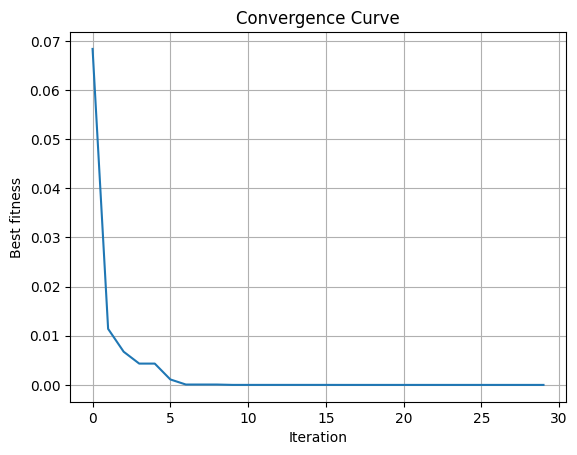

In [25]:
# Convergence plot
plt.plot(history)
plt.title("Convergence Curve")
plt.xlabel("Iteration")
plt.ylabel("Best fitness")
plt.grid(True)
plt.show()

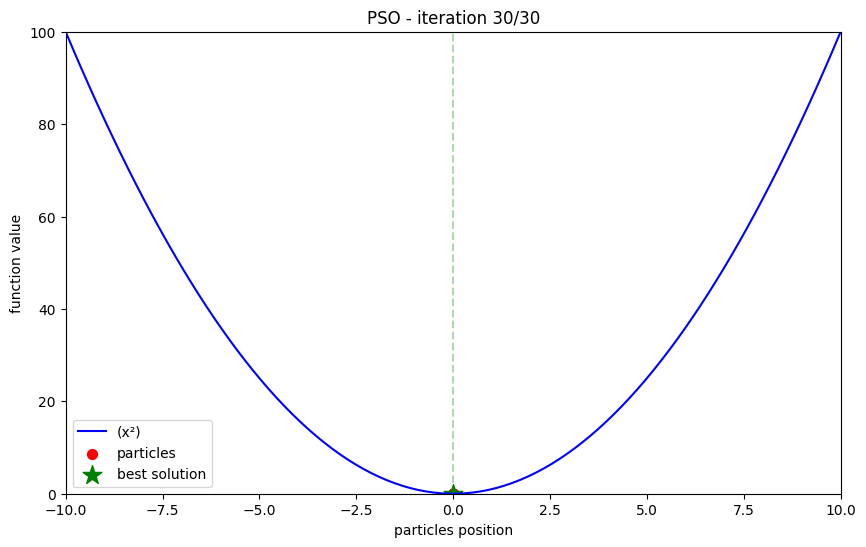

In [31]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
history_pos=np.array(history_pos)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(lower_bound, upper_bound)
ax.set_ylim(0, objective_function(upper_bound))
ax.set_xlabel('particles position')
ax.set_ylabel('function value')

x_vals = np.linspace(lower_bound, upper_bound, 100)

ax.plot(x_vals, objective_function(x_vals), 'b-', label='(x²)')


particles = ax.scatter([], [], c='r', s=50, label='particles')
best_particle = ax.scatter([], [], c='g', s=200, marker='*', label='best solution')
ax.axvline(gbest, color='g', linestyle='--', alpha=0.3)
ax.legend()
def init():
    particles.set_offsets(np.empty((0, 2)))
    best_particle.set_offsets(np.empty((0, 2)))
    return particles, best_particle

def update(frame):
    current_pos = history_pos[frame]
    particles.set_offsets(np.c_[current_pos, objective_function(current_pos)])
    current_gbest = history[frame]
    best_particle.set_offsets(np.c_[current_gbest, objective_function(current_gbest)])
    ax.set_title(f'PSO - iteration {frame+1}/{num_iterations}')

    return particles, best_particle

ani = FuncAnimation(fig, update, frames=num_iterations,init_func=init, blit=True, interval=300)

#plt.show()
# plt.close()
HTML(ani.to_jshtml())
